In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from tidepool_data_science_simulator.evaluation.inspect_results import load_results, load_result, collect_sims_and_results
from tidepool_data_science_simulator.utils import DATA_DIR

import matplotlib.pyplot as plt
import seaborn as sns

from tidepool_data_science_simulator.visualization.sim_viz import plot_sim_results
from tidepool_data_science_metrics.glucose.glucose import percent_values_ge_70_le_180, percent_values_gt_180, percent_values_lt_70, blood_glucose_risk_index
from scipy.stats import lognorm
from scipy.stats import ttest_ind
from scipy.stats import gaussian_kde


def calculate_cumulative_insulin(df):
    """
    Calculate cumulative insulin delivered from a DataFrame.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing insulin data with columns 'delivered_basal_insulin' and 'true_bolus'.
    
    Returns:
    tuple: Cumulative basal and bolus insulin.
    """
    cumulative_basal = df['delivered_basal_insulin'].sum()
    cumulative_bolus = df['true_bolus'].sum()
    return cumulative_basal + cumulative_bolus

def calculate_metrics(df):
    """
    Calculate key metrics from a DataFrame containing blood glucose and insulin data.

    Parameters:
    df (pd.DataFrame): DataFrame containing simulation data with at least the following columns:
                       - 'bg': Blood glucose values.
                       - 'delivered_basal_insulin': Delivered basal insulin values.
                       - 'true_bolus': Delivered bolus insulin values.

    Returns:
    tuple: A tuple containing the following metrics:
           - tir (float): Time in Range (percentage of blood glucose values between 70 and 180 mg/dL).
           - cumulative_insulin (float): Total cumulative insulin delivered (basal + bolus).
           - bgri (float): Blood Glucose Risk Index (a measure of glucose variability and risk).
    """
    # Calculate Time in Range (TIR) as the percentage of blood glucose values within the target range (70-180 mg/dL)
    tir = percent_values_ge_70_le_180(df['bg'])

    # Calculate percent of blood glucose values less than 70 mg/dL
    tbr = percent_values_lt_70(df['bg'])

    # Calculate percent of blood glucose values greater than 180 mg/dL
    tar = (df['bg'] > 180).mean() * 100

    # Calculate the total cumulative insulin delivered (sum of basal and bolus insulin)
    cumulative_insulin = calculate_cumulative_insulin(df)

    # Calculate the Blood Glucose Risk Index (BGRI), which quantifies glucose variability and risk
    bgri = blood_glucose_risk_index(df['bg'])[2]

    return tir, tbr, tar, cumulative_insulin, bgri

# Directory containing the files
directory = '/Users/mconn/tidepool/repositories/data-science-simulator/tidepool_data_science_simulator/projects/autobolus_application_factor/'

processed_dir = os.path.join(DATA_DIR, "processed/")

result_dir = 'autobolus_tempbasal_comparison_unannounced_meals_2025_05_28_T_13_03_11/'
# result_dir = 'autobolus_tempbasal_comparison_no_meals2025_05_28_T_14_12_00/'
# result_dir = 'autobolus_tempbasal_comparison_unannounced_meals_basal_cap2025_05_28_T_18_00_04/'
result_dir = 'autobolus_tempbasal_comparison_unannounced_meals_basal_cap_short_run2025_05_29_T_11_27_39/'
result_path = os.path.join(processed_dir, result_dir)

# Get list of files in the directory
files_0_0 = glob.glob(os.path.join(result_path, '*paf=0.0*tsv'))
files_0_4 = glob.glob(os.path.join(result_path, '*paf=0.4*tsv'))

# Group files by user and IBG
pairs = {}
for file in files_0_0 + files_0_4:
    base_name = os.path.basename(file)
    base_name = base_name.replace(".tsv", "")

    # Extract vp, patient_id, and ibg explicitly from the file name by splitting out tags, e.g., "vp=1_patient_id=1_ibg=0.0_paf=0.4"
    parts = [seg for seg in base_name.split("_") if "=" in seg]
    data = dict(seg.split("=", 1) for seg in parts) 
    
    # if float(data['ibg']) <= 70 or float(data['ibg']) >= 180:
    #     continue
    # if float(data['ibg']) != 200:
    #     continue

    user_ibg_key = f"vp={data['vp']}_patient_id={data['id']}_ibg={data['ibg']}"
    paf_value = "paf=0.0" if "paf=0.0" in base_name else "paf=0.4"

    if user_ibg_key not in pairs:
        pairs[user_ibg_key] = {"paf=0.0": [], "paf=0.4": []}

    pairs[user_ibg_key][paf_value].append(file)

# Load the histogram data
histogram_file = '/Users/mconn/Downloads/BG_Distribution_Histogram.csv'
histogram_df = pd.read_csv(histogram_file)

# Initialize a numpy array to store metrics
metrics_all = np.zeros((len(pairs), 5, 2)) 

# Initialize an array to store IBG values corresponding to each metric
ibg_values = np.zeros(len(pairs))

# Initialize weights array
weights = np.zeros(len(pairs))

# Loop through each user/IBG group and process files
for idx, (user_ibg_key, paf_files) in enumerate(pairs.items()):
    if paf_files["paf=0.0"] and paf_files["paf=0.4"]:
        dfs_0_0 = [load_result(file)[1] for file in paf_files["paf=0.0"]]
        dfs_0_4 = [load_result(file)[1] for file in paf_files["paf=0.4"]]

        # Combine dataframes for each PAF value
        df_0_0 = pd.concat(dfs_0_0, ignore_index=True)
        df_0_4 = pd.concat(dfs_0_4, ignore_index=True)

        # Calculate metrics for both conditions
        start_idx = 137
        end_idx = start_idx + 1*12
        metrics_0_0 = calculate_metrics(df_0_0[start_idx:end_idx])
        metrics_0_4 = calculate_metrics(df_0_4[start_idx:end_idx])
        print(metrics_0_0[3], metrics_0_4[3])
        # Extract IBG value from the user_ibg_key
        ibg = float(user_ibg_key.split("_ibg=")[1])
        ibg_values[idx] = ibg

        # Get the proportion corresponding to the IBG
        proportion = histogram_df.loc[histogram_df['ibg'] == ibg, 'proportion']
        if proportion.empty:
            raise ValueError(f"No matching proportion found for IBG={ibg} in the histogram file.")
        weights[idx] = proportion.values[0]

        # Store metrics in the numpy array
        metrics_all[idx] = [
            [metrics_0_0[0], metrics_0_4[0]],  # TIR
            [metrics_0_0[1], metrics_0_4[1]],  # TAR
            [metrics_0_0[2], metrics_0_4[2]],  # TBR
            [metrics_0_0[3], metrics_0_4[3]],  # Cumulative Insulin
            [metrics_0_0[4], metrics_0_4[4]]   # BGRI
        ]



/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the passed in array had glucose values greater than 402.
  warnings.warn("Some values in the passed in array had glucose values greater than 402.")
/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the passed in array had glucose values greater than 402.
  warnings.warn("Some values in the passed in array had glucose values greater than 402.")
/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the passed in array had glucose values greater than 402.
  warnings.warn("Some values in the passed in array had glucose values greater than 402.")
/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the 

Temp Basal (mode(s): 36.4, 99.7)
Autobolus (0.4) (mode(s): 36.0, 99.9)


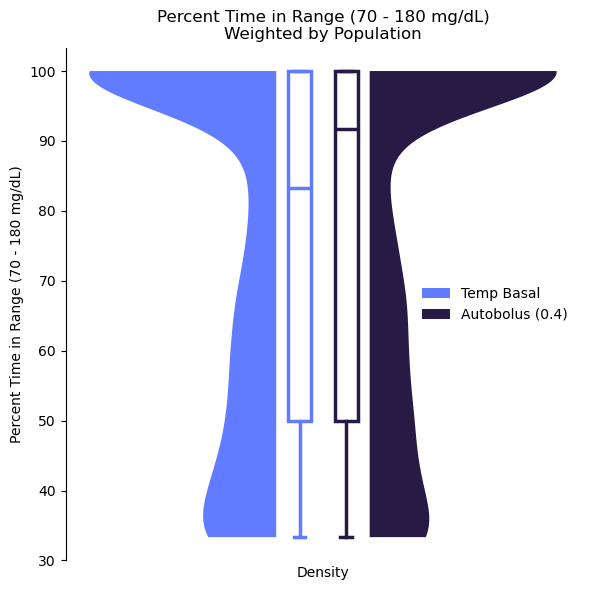

Error plotting Percent below Range (< 70 md/dL): The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.
Temp Basal (mode(s): 0.3, 63.6)
Autobolus (0.4) (mode(s): 0.1, 64.0)


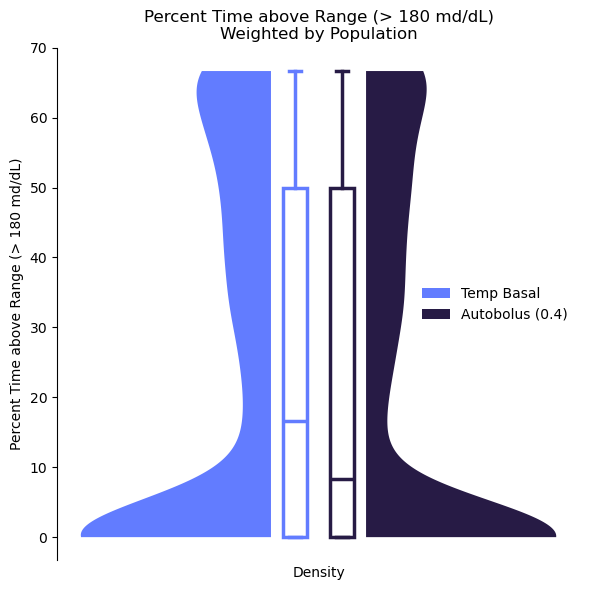

Temp Basal (mode(s): 1.9, 7.5)
Autobolus (0.4) (mode(s): 2.1, 8.7, 10.6, 12.4, 14.5, 16.4, 18.1)


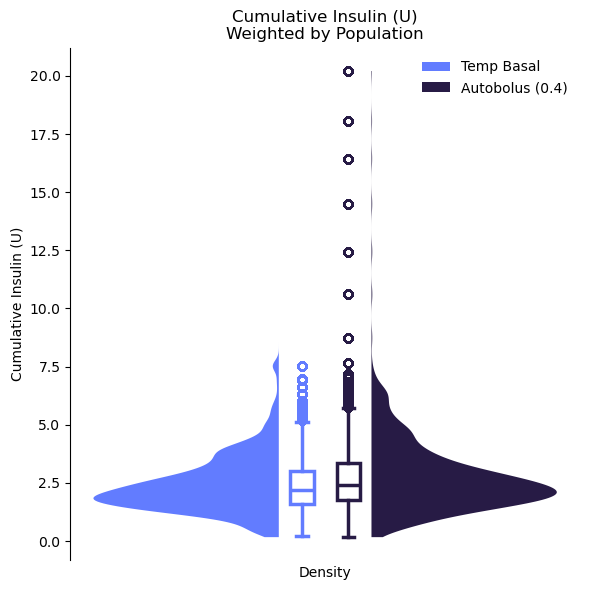

Temp Basal (mode(s): 2.8, 49.6, 73.2)
Autobolus (0.4) (mode(s): 2.8, 49.1, 72.5)


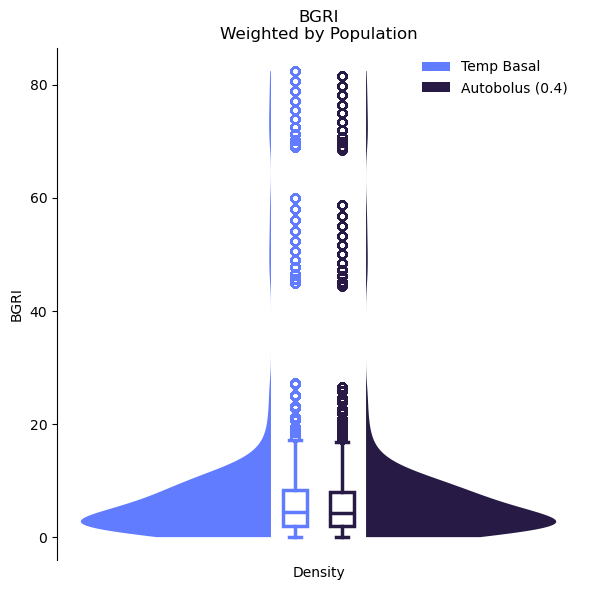

Metric: Percent Time in Range (70 - 180 mg/dL)
  Weighted:
    Temp Basal - Mean: 74.56, Std: 26.35, Median: 83.33, IQR: 50.00
    Autobolus (paf=0.4) - Mean: 76.40, Std: 26.19, Median: 91.67, IQR: 50.00
    t_stat: -1.30, t_p_value: 1.95e-01
    Mann-Whitney U: 561914.00, MWU p_value: 1.11e-01

Metric: Percent Time above Range (> 180 md/dL)
  Weighted:
    Temp Basal - Mean: 25.44, Std: 26.35, Median: 16.67, IQR: 50.00
    Autobolus (paf=0.4) - Mean: 23.60, Std: 26.19, Median: 8.33, IQR: 50.00
    t_stat: 1.30, t_p_value: 1.95e-01
    Mann-Whitney U: 604486.00, MWU p_value: 1.11e-01

Metric: Cumulative Insulin (U)
  Weighted:
    Temp Basal - Mean: 2.42, Std: 1.21, Median: 2.19, IQR: 1.42
    Autobolus (paf=0.4) - Mean: 2.77, Std: 1.71, Median: 2.39, IQR: 1.58
    t_stat: -4.85, t_p_value: 1.33e-06
    Mann-Whitney U: 531057.00, MWU p_value: 3.21e-04

Metric: BGRI
  Weighted:
    Temp Basal - Mean: 6.76, Std: 9.73, Median: 4.48, IQR: 6.25
    Autobolus (paf=0.4) - Mean: 6.50, Std: 9.6

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ttest_ind, mannwhitneyu
from scipy.signal import find_peaks

def weighted_percentile(values, weights, percentiles):
    """
    values: 1D numpy array
    weights: 1D numpy array of weights
    percentiles: list or array of percentiles (0-100)
    """
    sorted_indices = np.argsort(values)
    sorted_values = values[sorted_indices]
    sorted_weights = weights[sorted_indices]
    cum_weights = np.cumsum(sorted_weights)
    total_weight = cum_weights[-1]
    percentile_ranks = 100 * cum_weights / total_weight

    return np.interp(percentiles, percentile_ranks, sorted_values)

def weighted_iqr(values, weights):
    q1, q3 = weighted_percentile(values, weights, [25, 75])
    return q3 - q1

def compare_kde_boxplot(
    data_1,
    data_2,
    weights=None,
    title="Comparison",
    ylabel="Value",
    label_1="Dataset 1",
    label_2="Dataset 2",
    color_1="#627cff",
    color_2="#271b45",
    bw_method=0.2,
    violin_width=0.4,
    box_width=0.05
):
    """
    Compare two datasets using KDEs and boxplots on a shared vertical axis.

    Parameters:
        data1: First dataset (1D array).
        data2: Second dataset (1D array).
        weights: Optional weights for computing KDE.
        title: Plot title.
        ylabel: Y-axis label.
        label1, label2: Labels for datasets.
        color1, color2: Colors for KDE and boxplot lines.
        bw_method: Bandwidth for KDE.
        violin_width: Max width of violin KDEs.
        box_width: Width of boxplots.
    """
    x_min = min(data_1.min(), data_2.min())
    x_max = max(data_1.max() , data_2.max())
    x_grid = np.linspace(x_min, x_max, 500)

    # KDEs
    kde_1 = gaussian_kde(data_1, weights=weights, bw_method=bw_method) 
    kde_2 = gaussian_kde(data_2, weights=weights, bw_method=bw_method)

    density_1 = kde_1(x_grid)
    density_2 = kde_2(x_grid)

    peaks_1, _ = find_peaks(density_1)
    modes_1 = x_grid[peaks_1]

    peaks_2, _ = find_peaks(density_2)
    modes_2 = x_grid[peaks_2]

    # Normalize KDEs
    density_1 /= density_1.max()
    density_2 /= density_2.max()

    # Add modes to labels
    print(f"{label_1} (mode(s): {', '.join([f'{m:.1f}' for m in modes_1])})" if len(modes_1) > 0 else label_1)
    print(f"{label_2} (mode(s): {', '.join([f'{m:.1f}' for m in modes_2])})" if len(modes_2) > 0 else label_2)
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.fill_betweenx(x_grid, (-density_1 * violin_width) - 0.1, -0.1, facecolor=color_1, alpha=1, label=label_1)
    ax.fill_betweenx(x_grid, 0.1, (density_2 * violin_width) + 0.1, facecolor=color_2, alpha=1, label=label_2)

    # Boxplots
    data_1_weighted = np.repeat(data_1, (weights * 10000).astype(int))
    data_2_weighted = np.repeat(data_2, (weights * 10000).astype(int))

    box_data = [data_1_weighted, data_2_weighted]
    positions = [-0.05, 0.05]
    box = ax.boxplot(box_data, vert=True, positions=positions, widths=box_width, patch_artist=True)

    line_width = 2.5
    for i, color in enumerate([color_1, color_2]):
        box['boxes'][i].set_facecolor('none')
        box['boxes'][i].set_edgecolor(color)
        box['boxes'][i].set_linewidth(line_width)

        box['medians'][i].set_color(color)
        box['medians'][i].set_linewidth(line_width)

        for j in [2*i, 2*i+1]:  # whiskers and caps
            box['whiskers'][j].set_color(color)
            box['whiskers'][j].set_linewidth(line_width)
            box['caps'][j].set_color(color)
            box['caps'][j].set_linewidth(line_width)

        if 'fliers' in box and i < len(box['fliers']):
            box['fliers'][i].set_markeredgecolor(color)
            box['fliers'][i].set_linewidth(line_width)

    ax.set_xlabel('Density')
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    plt.tight_layout()
    plt.show()

metric_names = ['Percent Time in Range (70 - 180 mg/dL)', 
    'Percent below Range (< 70 md/dL)', 
    'Percent Time above Range (> 180 md/dL)', 
    'Cumulative Insulin (U)', 
    'BGRI']

statistical_details = {}

for i, name in enumerate(metric_names):
    data_1 = metrics_all[:, i, 0]
    data_2 = metrics_all[:, i, 1]
    
    try:
        compare_kde_boxplot(data_1, data_2,
                            weights=weights,
                            title=f"{name}\nWeighted by Population",
                            ylabel=name,
                            label_1="Temp Basal", label_2="Autobolus (0.4)")
    except Exception as e:
        print(f"Error plotting {name}: {e}")
        continue
    
    # Perform a t-test between the two conditions
    t_stat, p_value = ttest_ind(data_1, data_2, equal_var=False)
    
    # Mann-Whitney U test
    u_stat, mw_p_value = mannwhitneyu(data_1, data_2, alternative='two-sided')
    
    # Medians and IQRs
    weighted_median_1 = weighted_percentile(data_1, weights, 50)
    weighted_median_2 = weighted_percentile(data_2, weights, 50)

    weighted_iqr_1 = weighted_iqr(data_1, weights)
    weighted_iqr_2 = weighted_iqr(data_2, weights)

    # Weighted mean calculation
    weighted_mean_1 = np.average(data_1, weights=weights)
    weighted_mean_2 = np.average(data_2, weights=weights)

    # Weighted standard deviation calculation
    variance_1 = np.average((data_1-weighted_mean_1)**2, weights=weights)
    weighted_std_1 = np.sqrt(variance_1)
    variance_2 = np.average((data_2-weighted_mean_2)**2, weights=weights)
    weighted_std_2 = np.sqrt(variance_2)

    # Save statistical details
    statistical_details[name] = {
        "Weighted": {
            "Temp Basal": {
                "mean": weighted_mean_1,
                "std": weighted_std_1,
                "median": weighted_median_1,
                "iqr": weighted_iqr_1
            },
            "Autobolus (paf=0.4)": {
                "mean": weighted_mean_2,
                "std": weighted_std_2,
                "median": weighted_median_2,
                "iqr": weighted_iqr_2
            },
            "t_stat": t_stat,
            "p_value": p_value,
            "mannwhitney_u_stat": u_stat,
            "mannwhitney_p_value": mw_p_value
        }
    }

for metric_name, details in statistical_details.items():
    print(f"Metric: {metric_name}")
    for scaling, stats in details.items():
        print(f"  {scaling}:")
        print(f"    Temp Basal - Mean: {stats['Temp Basal']['mean']:.2f}, Std: {stats['Temp Basal']['std']:.2f}, Median: {stats['Temp Basal']['median']:.2f}, IQR: {stats['Temp Basal']['iqr']:.2f}")
        print(f"    Autobolus (paf=0.4) - Mean: {stats['Autobolus (paf=0.4)']['mean']:.2f}, Std: {stats['Autobolus (paf=0.4)']['std']:.2f}, Median: {stats['Autobolus (paf=0.4)']['median']:.2f}, IQR: {stats['Autobolus (paf=0.4)']['iqr']:.2f}")
        print(f"    t_stat: {stats['t_stat']:.2f}, t_p_value: {stats['p_value']:.2e}")
        print(f"    Mann-Whitney U: {stats['mannwhitney_u_stat']:.2f}, MWU p_value: {stats['mannwhitney_p_value']:.2e}")
    print()

In [94]:
len(range(40,400,5))

72

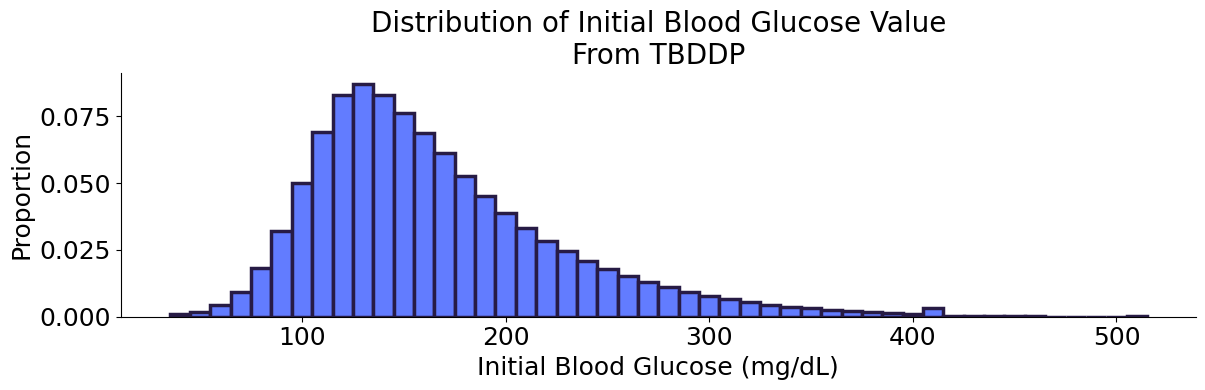

In [95]:
import matplotlib.pyplot as plt

def plot_ibg_histogram(histogram_df, font_size=18):
    # Set up plot aesthetics
    fig, ax = plt.subplots(figsize=(12, 4))
    bar_color = "#627cff"
    edge_color = "#271b45"

    # Extract data
    x = histogram_df['ibg'].values
    heights = histogram_df['proportion'].values

    # Plot the bar chart
    ax.bar(x, heights, width=10.0, color=bar_color, edgecolor=edge_color, linewidth=2.5)

    # Labeling and formatting
    ax.set_xlabel("Initial Blood Glucose (mg/dL)", fontsize=font_size)
    ax.set_ylabel("Proportion", fontsize=font_size)
    ax.set_title("Distribution of Initial Blood Glucose Value\nFrom TBDDP", fontsize=font_size + 2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=font_size)

    # Final layout and display
    plt.tight_layout()
    plt.show()

plot_ibg_histogram(histogram_df, font_size=18)

In [96]:
from collections import Counter

data = [1, 1, 1, 2, 2, 3, 4, 4, 4, 5]
counts = Counter(data)
max_count = max(counts.values())
modes = [k for k, v in counts.items() if v == max_count]

print("Modes:", modes)
print("Max count:", max_count)

Modes: [1, 4]
Max count: 3
